In [1]:
#Library
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [2]:
# --- PHASE 1: REPRODUCIBILITY AND HYPERPARAMETERS ---
SEED = 42
EPOCHS = 100
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [3]:
# 1. Loading the datasets
red_wine = pd.read_csv('winequality_red.csv', sep=';')
white_wine = pd.read_csv('winequality_white.csv', sep=';')

# 2. Add the Type column (Red=0, White=1)
red_wine['type'] = 0
white_wine['type'] = 1

# 3. Connect the two tables vertically.
df_wine = pd.concat([red_wine, white_wine], axis=0)

#4. Reset the index (so it doesn't stay messy after Concat)
df_wine = df_wine.reset_index(drop=True)

# General information about data
print(f"Kırmızı şarap satır sayısı: {len(red_wine)}")
print(f"Beyaz şarap satır sayısı: {len(white_wine)}")
print(f"Toplam (Birleşik) satır sayısı: {len(df_wine)}")
print("\nBirleşmiş Veri Seti (İlk 5 Satır):")
print(df_wine.head())

Kırmızı şarap satır sayısı: 1599
Beyaz şarap satır sayısı: 4898
Toplam (Birleşik) satır sayısı: 6497

Birleşmiş Veri Seti (İlk 5 Satır):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0  

In [4]:
df_wine.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [5]:
# We check if there are any "None" (missing) values in the columns.
missing_report = df_wine.isnull().sum()
print(f"\nTotal number of missing cells: {df_wine.isnull().sum().sum()}")
row_number = len(df_wine)
print(f"Total number of rows: {row_number}")


Total number of missing cells: 0
Total number of rows: 6497


In [6]:
# Feature-Target Separation
X = df_wine.drop("quality", axis=1).values
y = df_wine["quality"].values

# Data Splitting (70% Train, 15% Validation, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

# Feature Scaling (Standardization)
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [7]:
# Conversion to PyTorch Tensors
def to_tensor(data):
    return torch.tensor(data, dtype=torch.float32).to(DEVICE)

X_train_tensor = to_tensor(X_train_scaled)
y_train_tensor = to_tensor(y_train_scaled)
X_val_tensor = to_tensor(X_val_scaled)
y_val_tensor = to_tensor(y_val_scaled)
X_test_tensor = to_tensor(X_test_scaled)
y_test_tensor = to_tensor(y_test_scaled)

In [8]:
# --- PHASE 3: ARCHITECTURE DEFINITION ---
class WineQualityMLP(nn.Module):
    """Wine Quality tahmini için tasarlanmış MLP mimarisi."""
    def __init__(self, input_dim):
        super(WineQualityMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-7))) * 100

In [9]:
# Loss Functions
loss_criteria = {
    "MSE": nn.MSELoss(),
    "MAE (L1)": nn.L1Loss(),
    "Huber": nn.HuberLoss(delta=1.0),
    "Log-Cosh": lambda y_p, y_t: torch.mean(torch.log(torch.cosh(y_p - y_t)))
}

Executing Experiment: MSE Loss
Executing Experiment: MAE (L1) Loss
Executing Experiment: Huber Loss
Executing Experiment: Log-Cosh Loss


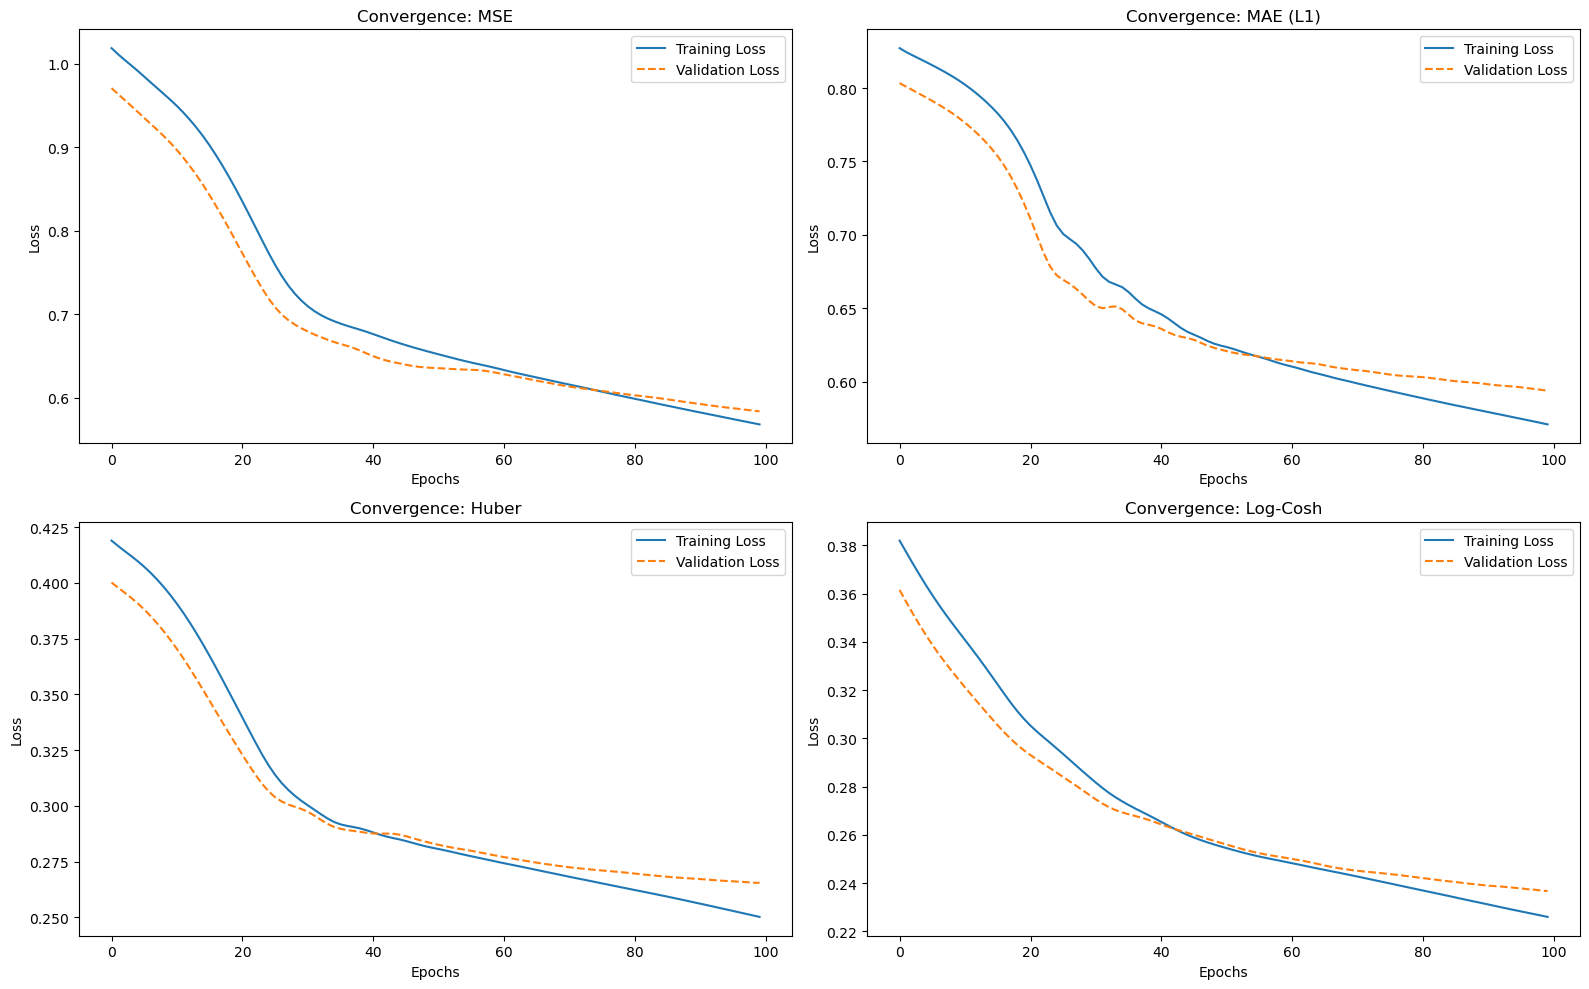

In [10]:
# --- PHASE 4: EXPERIMENTATION ---
results = {}
plt.figure(figsize=(16, 10))

for idx, (name, criterion) in enumerate(loss_criteria.items()):
    print(f"Executing Experiment: {name} Loss")
    
    # A new model instance is created for each experiment.
    model = WineQualityMLP(X_train_tensor.shape[1]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    train_log, val_log = [], []
    
    for epoch in range(EPOCHS):
        # Education
        model.train()
        optimizer.zero_grad()
        preds = model(X_train_tensor)
        loss = criterion(preds, y_train_tensor)
        loss.backward()
        optimizer.step()
        train_log.append(loss.item())
        
        # Verification
        model.eval()
        with torch.no_grad():
            v_preds = model(X_val_tensor)
            v_loss = criterion(v_preds, y_val_tensor)
            val_log.append(v_loss.item())

    # Graphic Drawing
    plt.subplot(2, 2, idx + 1)
    plt.plot(train_log, label='Training Loss')
    plt.plot(val_log, label='Validation Loss', linestyle='--')
    plt.title(f'Convergence: {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Test Performance
    model.eval()
    with torch.no_grad():
        test_output = model(X_test_tensor).cpu().numpy()
        y_pred_final = scaler_y.inverse_transform(test_output)
        y_true_final = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())
        
        results[name] = {
            "MAE (Score)": mean_absolute_error(y_true_final, y_pred_final),
            "RMSE (Score)": np.sqrt(mean_squared_error(y_true_final, y_pred_final)),
            "R2 Score": r2_score(y_true_final, y_pred_final),
            "MAPE (%)": calculate_mape(y_true_final, y_pred_final)
        }

plt.tight_layout()
plt.show()

In [11]:
# --- PHASE 5: SUMMARY ---
df_results = pd.DataFrame(results).T
print("\nFinal Performance Table:")
print(df_results)


Final Performance Table:
          MAE (Score)  RMSE (Score)  R2 Score  MAPE (%)
MSE          0.527369      0.663884  0.383913  9.350762
MAE (L1)     0.513740      0.692731  0.329209  9.062603
Huber        0.524017      0.665671  0.380592  9.277550
Log-Cosh     0.519579      0.664799  0.382213  9.220979


In [12]:
quality_counts = df_wine['quality'].value_counts().sort_index()
print("Quality Score Distribution:")
print(quality_counts)

Quality Score Distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64
